# Block 1 — Introduction in Time Series Data: Exploratory Data Analysis

**Goals for this block:**
- Load data from csv/parquet
- visualize data using plotly, matplotlib and seaborn
- analyze autocorrelation and stationarity of time series datasets

## 0. Setup & Environment

Let's import the necessary libraries for time series analysis and visualization.

In [1]:
# GUIDED: imports and environment checks
import numpy as np
import pandas as pd

import warnings
warnings.filterwarnings('ignore')

## 1. Data Loading and Initial Exploration

We'll work with the well-known **air passengers** dataset that contains typical patterns in time series data.

In [2]:
# GUIDED: load data
df = pd.read_csv("air_passengers.csv")

In [3]:
df.head(6)

,timestamp,#Passengers
0,1949-01-01,112.0
1,1949-02-01,118.0
2,1949-03-01,132.0
3,1949-04-01,129.0
4,1949-05-01,121.0
5,1949-06-01,135.0


In [4]:
# parse a timestamp column smartly
df['timestamp'] = pd.to_datetime(df['timestamp'])
df.head(6)

,timestamp,#Passengers
0,1949-01-01,112.0
1,1949-02-01,118.0
2,1949-03-01,132.0
3,1949-04-01,129.0
4,1949-05-01,121.0
5,1949-06-01,135.0


In [5]:
df.index.freq = 'MS'  # monthly start frequency

In [6]:
df.set_index('timestamp', inplace=True)
df.head(6)

,#Passengers
timestamp,
1949-01-01,112.0
1949-02-01,118.0
1949-03-01,132.0
1949-04-01,129.0
1949-05-01,121.0
1949-06-01,135.0


### 1.1 Data visualization

Effective visualization is essential for understanding time series data patterns, identifying anomalies, and communicating insights. We'll explore three powerful visualization libraries:

- **Matplotlib**: Foundation library, highly customizable, great for static plots
- **Seaborn**: Statistical plotting, beautiful defaults, excellent for distributions and correlations  
- **Plotly**: Interactive plots, great for exploration and dashboards

<Axes: title={'center': 'Air Passengers'}, xlabel='Timestamp (hour)', ylabel='# passengers'>

<Figure size 1000x300 with 0 Axes>

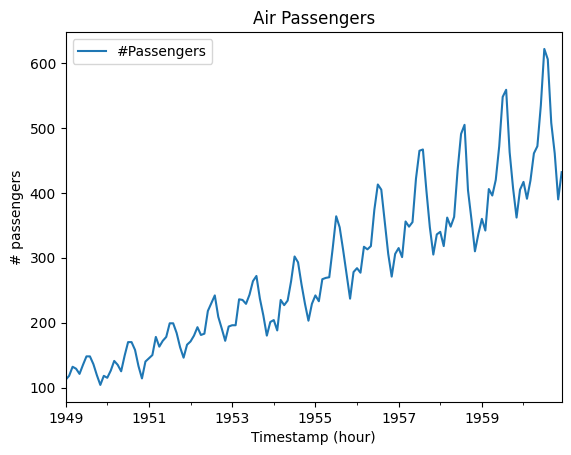

In [8]:
# GUIDED: visualize raw series using matplotlib
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 3))
df.plot(title='Air Passengers', xlabel='Timestamp (hour)', ylabel='# passengers')

In [9]:
# GUIDED: visualize raw series using plotly

import plotly.express as px
px.line(df, x=df.index, y=df['#Passengers'])

<Axes: xlabel='#Passengers', ylabel='Density'>

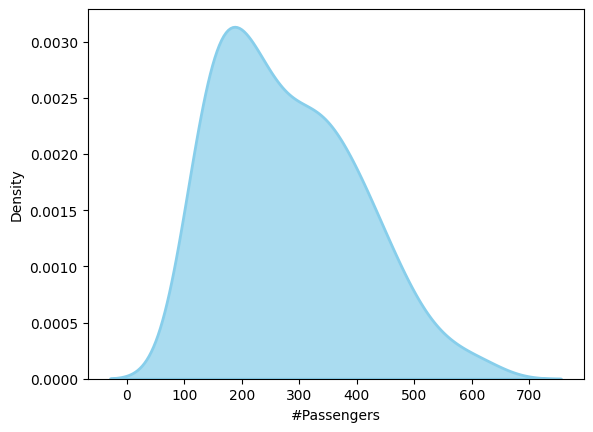

In [10]:
# Guided: vizualize the series density using seaborn

import seaborn as sns
sns.kdeplot(data=df, x='#Passengers', fill=True, color='skyblue',
            alpha=0.7, linewidth=2)

## 2. Seasonal Decomposition of Time Series

Seasonal decomposition is a fundamental technique for understanding the underlying patterns in time series data by separating it into distinct components:

### Components of Time Series:
- **Trend**: Long-term movement or direction in the data
- **Seasonal**: Regular, predictable patterns that repeat over fixed periods
- **Residual/Noise**: Random fluctuations after removing trend and seasonality

### Decomposition Models:
- **Additive**: `Y(t) = Trend(t) + Seasonal(t) + Residual(t)`
  - Seasonal fluctuations are relatively constant over time
- **Multiplicative**: `Y(t) = Trend(t) × Seasonal(t) × Residual(t)`  
  - Seasonal fluctuations change proportionally with the trend


In [11]:
from statsmodels.tsa.seasonal import seasonal_decompose

In [12]:
# GUIDED: Classical Seasonal Decomposition 

# Perform  decomposition
decomposition = seasonal_decompose(
    df, 
    model='additive',               # Try 'multiplicative' as well
    period=12,                      # Monthly seasonality for daily data
    extrapolate_trend='freq'
)



📊 Decomposition Statistics:
Trend variance: 12604.17
Seasonal variance: 1467.89
Residual variance: 450.74


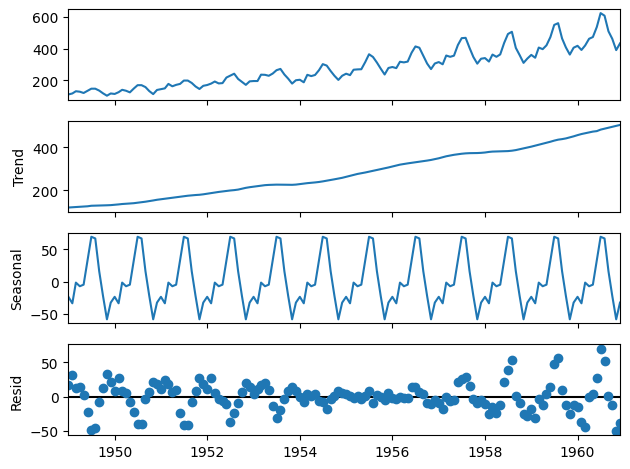

In [13]:
decomposition.plot()

# Print decomposition statistics
print(f"\n📊 Decomposition Statistics:")
print(f"Trend variance: {decomposition.trend.var():.2f}")
print(f"Seasonal variance: {decomposition.seasonal.var():.2f}")
print(f"Residual variance: {decomposition.resid.var():.2f}")

##### What This Means:

1. **Trend Variance (12604.17) - HIGHEST** 
   - **85.7%** of your data's variation comes from long-term trends

2. **Seasonal Variance (1467.89) - MEDIUM** 
   - **10.0%** of variation comes from seasonal patterns

3. **Residual Variance (450.74) - LOWEST** 
   - **3.1%** is unexplained random noise


##### Practical Recommendations:

| Residual % | Data Quality | Forecasting Outlook |
|------------|-------------|---------------------|
| < 15% | Excellent | Very predictable |
| 15-30% | Good | Predictable |
| 30-50% | Fair | Moderately predictable |
| > 50% | Poor | Difficult to forecast |

## 3. Autocorrelation Analysis (ACF & PACF)

Autocorrelation analysis helps us understand how a time series is related to its past values. This is crucial for:
- Identifying seasonal patterns
- Selecting appropriate forecasting models (e.g., ARIMA parameters)
- Understanding the "memory" of the time series

**ACF (Autocorrelation Function)**
- Measures correlation between observations at different time lags
- Includes both direct and indirect correlations
- Useful for identifying the moving average (MA) order in ARIMA models

**PACF (Partial Autocorrelation Function)**
- Measures correlation between observations after removing effects of intermediate lags
- Shows only direct correlations
- Useful for identifying the autoregressive (AR) order in ARIMA models


In [14]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

<Axes: xlabel='timestamp'>

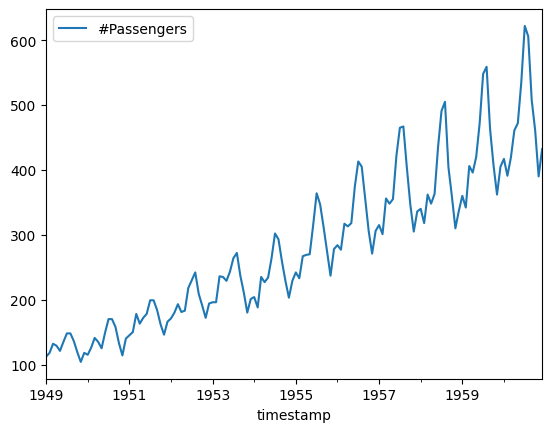

In [15]:
df.plot()

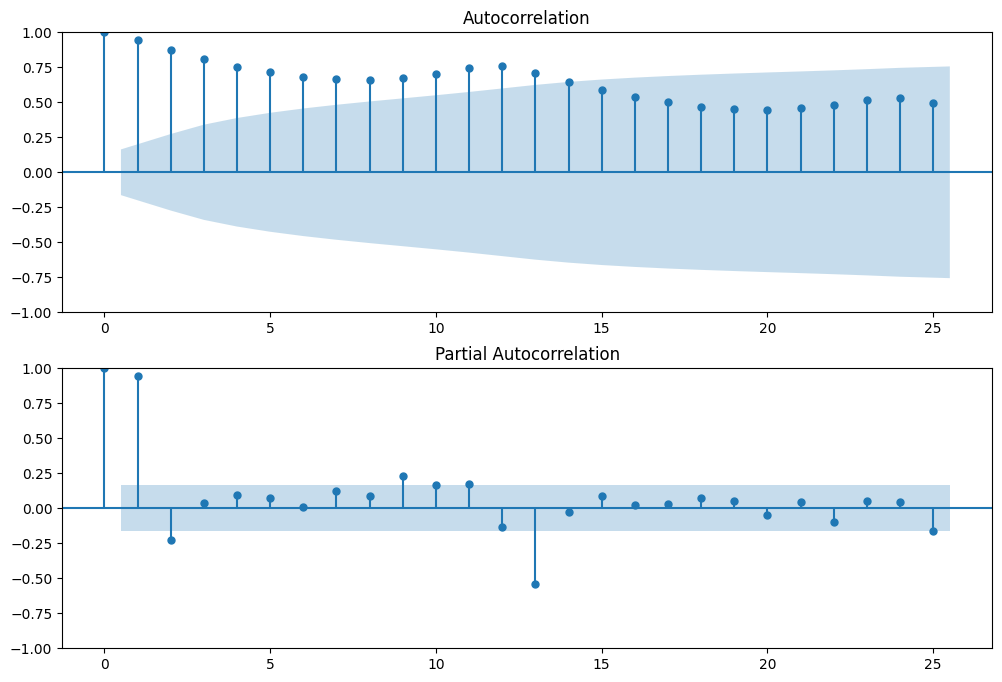

In [16]:
# Plot ACF & PACF

fig, axes = plt.subplots(2, 1, figsize=(12, 8))
plot_acf(df['#Passengers'], lags=25, ax=axes[0])
plot_pacf(df['#Passengers'], lags=25, ax=axes[1])
plt.show()

##### What to Look For:

**In the Air Passengers Dataset:**
1. **ACF**: Should show gradual decay with seasonal spikes every 12 lags (annual seasonality)
2. **PACF**: Should show significant correlations at early lags and seasonal lags
3. **Slow ACF decay** indicates presence of trend (non-stationary)
4. **Seasonal spikes** at lag 12, 24, 36... confirm monthly seasonality

**Next Steps Based on ACF/PACF:**
- If slow ACF decay → Apply differencing to remove trend
- If seasonal spikes → Consider seasonal differencing
- Use cutoff patterns → Determine ARIMA(p,d,q) parameters

## 4. Time Series Stationarity

Stationarity is a fundamental concept in time series analysis. A stationary time series has statistical properties (mean, variance, autocorrelation) that remain constant over time.

### Types of Stationarity:
- **Strict Stationarity**: All statistical properties are constant over time
- **Weak Stationarity**: Mean, variance, and autocovariance are constant over time

### Common Non-Stationary Patterns:
- **Trend**: Long-term increase or decrease in the data
- **Changing Variance**: Variance increases or decreases over time
- **Structural Breaks**: Sudden changes in statistical properties

In [17]:
# Differenciating/ Detrending
# First-order differencing (removes linear trend)
# Seasonal differencing (removes seasonality) -> 12 months for yearly seasonality

detrended_diff = df.diff(12).diff(1).dropna()

Text(0, 0.5, '#Passengers')

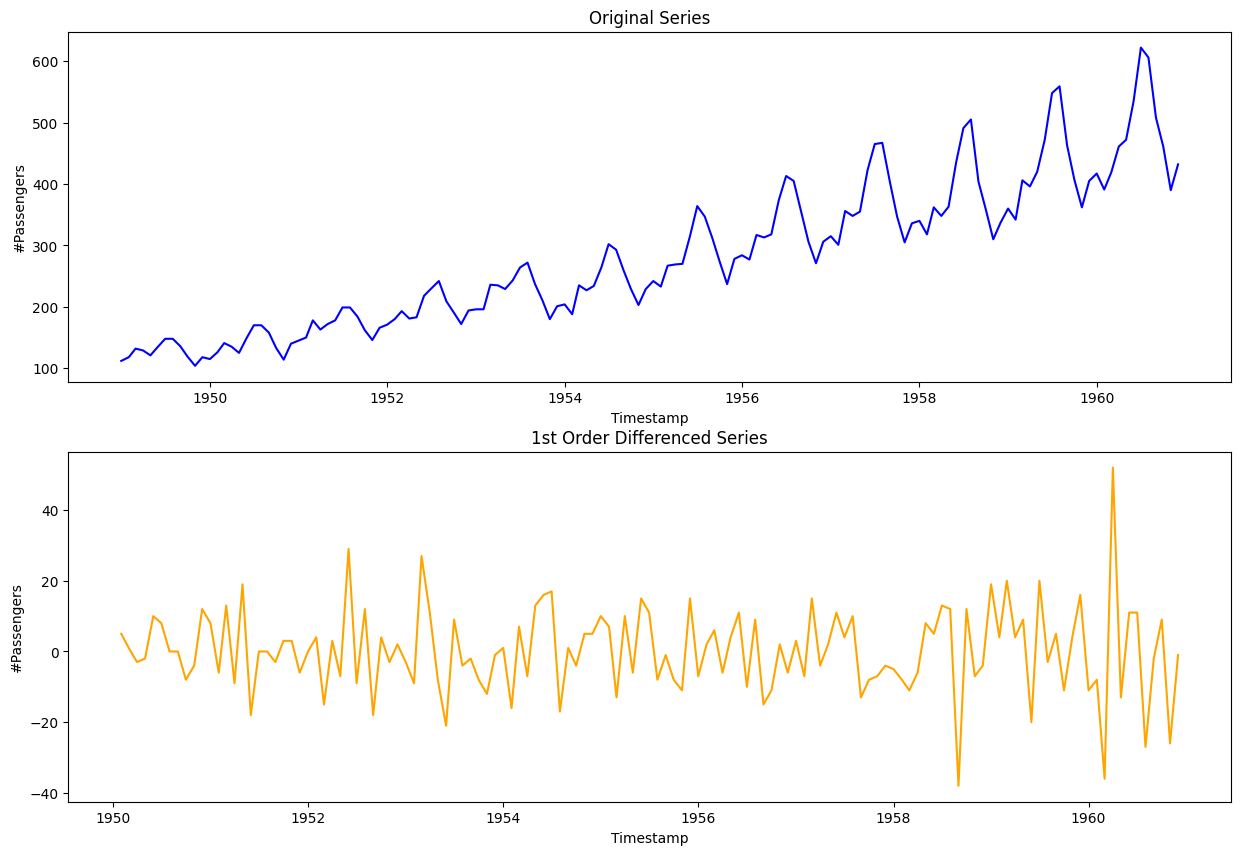

In [18]:
fig, axes = plt.subplots(2, 1, figsize=(15, 10))
    
# Original series
axes[0].plot(df["#Passengers"], color='blue', linewidth=1.5, label='Original')
axes[0].set_title('Original Series')
axes[0].set_xlabel('Timestamp')
axes[0].set_ylabel('#Passengers')

axes[1].plot(detrended_diff["#Passengers"], color='orange', linewidth=1.5, label='1st Order Differencing')
axes[1].set_title('1st Order Differenced Series')
axes[1].set_xlabel('Timestamp')
axes[1].set_ylabel('#Passengers')

<div style="background-color: #ffedcc; border-left: 6px solid #ff7518; padding: 10px; margin-bottom: 10px;">
<h2>📝 Exercise: Data Preparation</h2>

Complete the following tasks with the `de_energy_dataset_filled.csv` dataset:
1. load and visualize the raw data
2. decompose the time-series
   - Hint: select one-by-one the energy sources (e.g. "Fossil")
3. run ACF and PACF
   - interpret the plots. What do you see?
4. if the data are non-stationary you can differentiate
5. Select another energy source and repeat

This exercise will help reinforce the concepts of decomposition and autocorrelation in time series.
</div>

In [19]:
# Load exercise data

df_excercise = pd.read_csv("de_energy_dataset_filled.csv")
#df_excercise['timestamp'] = ...

df_excercise['timestamp'] = pd.to_datetime(df_excercise['timestamp'])
df_excercise = df_excercise.set_index('timestamp').sort_index()
df_excercise.index.freq = 'MS'


In [20]:
df_excercise.head(6)

,Fossil,Wind,Solar
timestamp,,,
2016-01-01,37521,9771,702
2016-02-01,32023,10371,1350
2016-03-01,35256,6331,2591
2016-04-01,30078,6235,4129
2016-05-01,27404,6445,5190
2016-06-01,27909,4434,5436


<Figure size 1000x300 with 0 Axes>

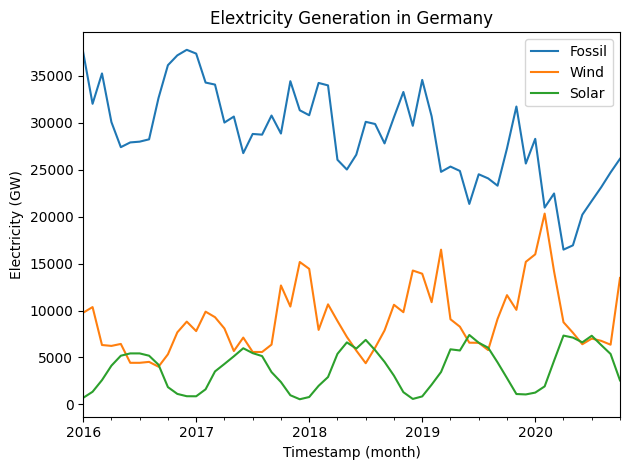

In [ ]:
# visualize raw series: it should contain the different energy sources "Solar", "Wind", "Fossile"

plt.figure(figsize=(10, 3))
df_excercise.plot(title='Elextricity Generation in Germany', xlabel='Timestamp (month)', ylabel='Electricity (GW)')
plt.tight_layout()
plt.show()

In [ ]:
# Perform  decomposition only one energy source e.g., "Solar"

energy_source = "Fossil"
df_univariate = df_excercise[energy_source]

decomposition_ex = seasonal_decompose(
    df_univariate, 
    model='additive',               # Try 'multiplicative' as well
    period=12,                      # Monthly seasonality for daily data
    extrapolate_trend='freq'
)


📊 Decomposition Statistics:
Trend variance: 16213621.43
Seasonal variance: 8504386.27
Residual variance: 4133212.91


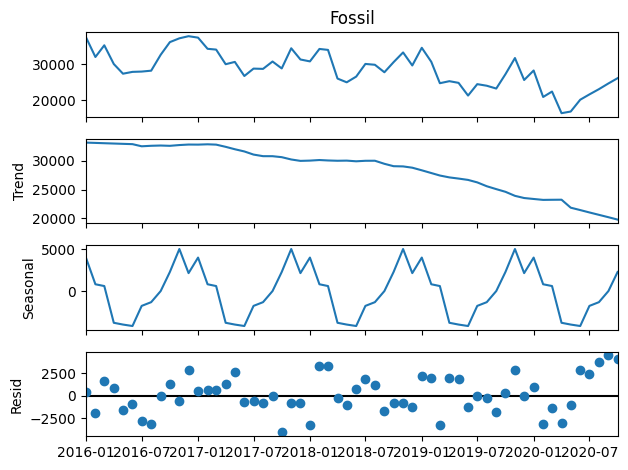

In [23]:
decomposition_ex.plot()


# Print decomposition statistics
print(f"\n📊 Decomposition Statistics:")
print(f"Trend variance: {decomposition_ex.trend.var():.2f}")
print(f"Seasonal variance: {decomposition_ex.seasonal.var():.2f}")
print(f"Residual variance: {decomposition_ex.resid.var():.2f}")

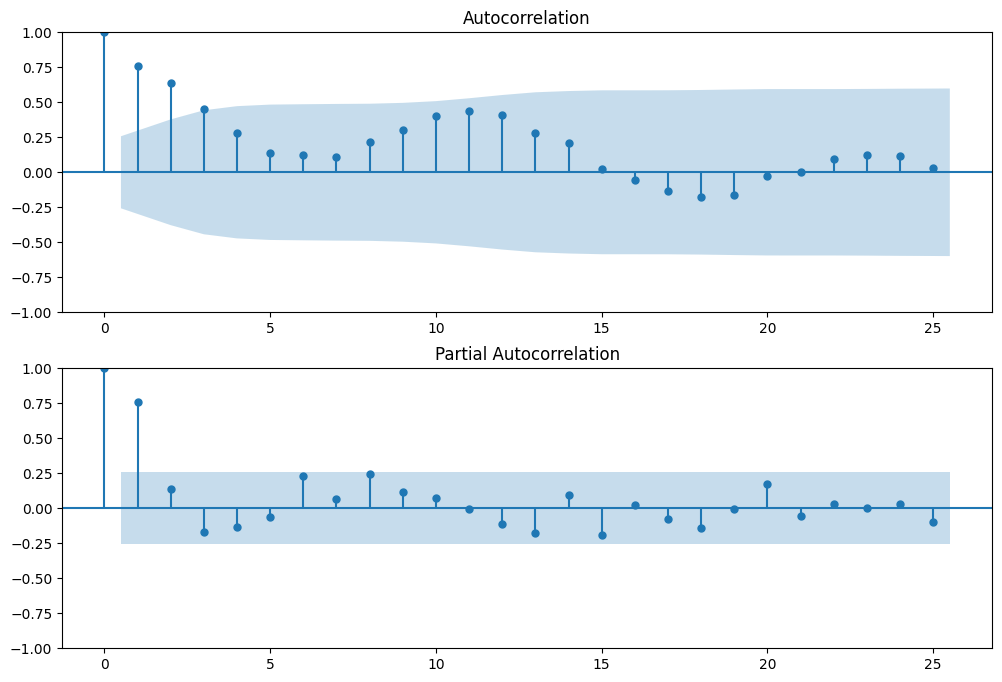

In [24]:
# Plot ACF & PACF

fig, axes = plt.subplots(2, 1, figsize=(12, 8))
plot_acf(df_univariate, lags=25, ax=axes[0])
plot_pacf(df_univariate, lags=25, ax=axes[1])
plt.show()

In [25]:
# Differenciating/ Detrending
# First-order differencing (removes linear trend)
# Seasonal differencing (removes seasonality) -> 12 months for yearly seasonality

detrended_diff_ex = df_excercise.diff(12).diff(1).dropna()

Text(0, 0.5, 'Value (MW)')

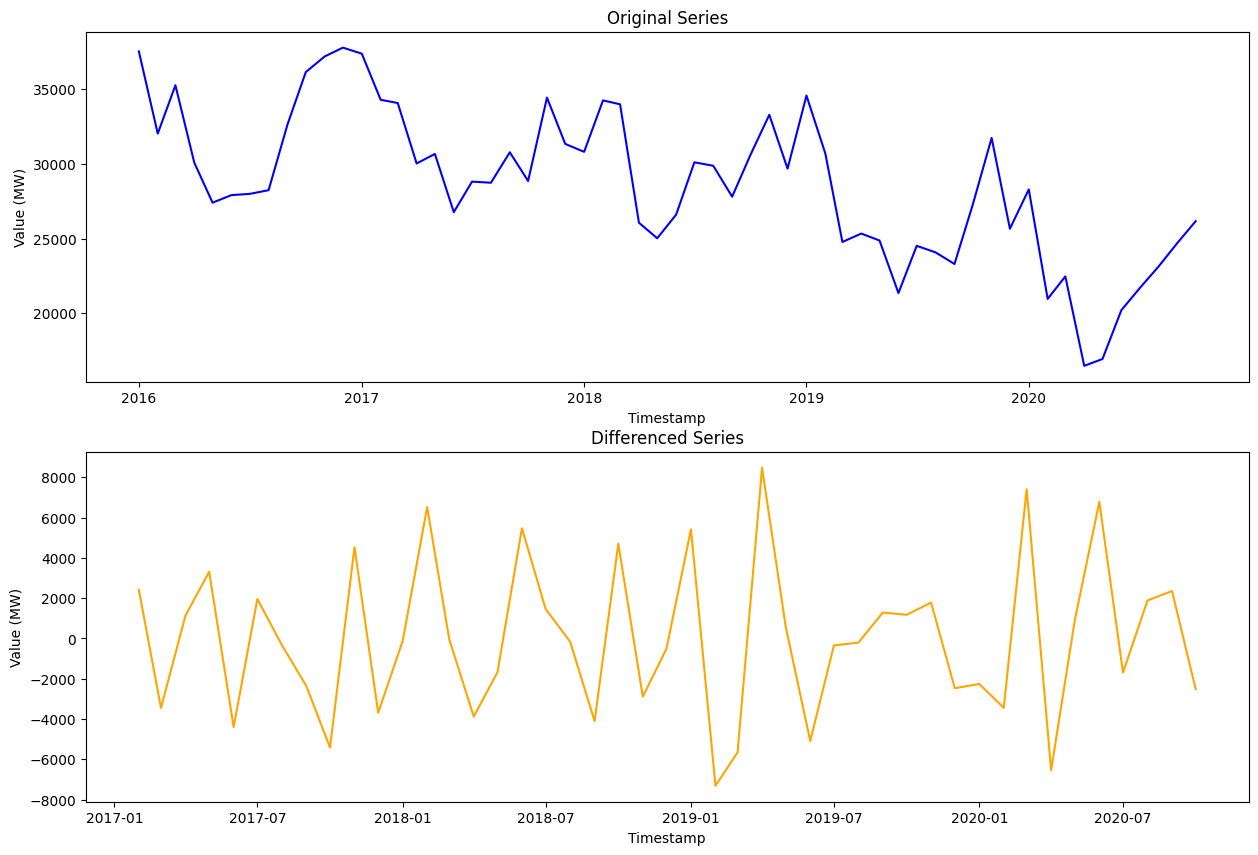

In [ ]:
# Plot original and detrended series
fig, axes = plt.subplots(2, 1, figsize=(15, 10))

# Original series
axes[0].plot(df_excercise[energy_source], color='blue', linewidth=1.5, label='Original')
axes[0].set_title('Original Series')
axes[0].set_xlabel('Timestamp')
axes[0].set_ylabel('Value (MW)')

axes[1].plot(detrended_diff_ex[energy_source], color='orange', linewidth=1.5, label='1st Order Differencing')
axes[1].set_title('Differenced Series')
axes[1].set_xlabel('Timestamp')
axes[1].set_ylabel('Value (MW)')


## ✅ Summary

### What You've Accomplished:

- Loaded and visualized time series data using Matplotlib, Plotly, and Seaborn
- Separated time series into trend, seasonal, and residual components
- Analyzed ACF and PACF plots to understand temporal dependencies
- Identified seasonal patterns and trend presence
- Applied trend and seasonal differencing
- Verified stationarity improvements through visualization and ACF/PACF

These exploratory techniques are essential for selecting appropriate forecasting models.